# CIFAR-10 分类 —— VGG11 + ResNet18 双模型对比（卷积神经网络CNN2.md）

本脚本实现了 CIFAR-10 数据集的 10 分类任务，整合了以下内容：
1. Kaggle 数据准备
2. 自定义 CIFAR10WithCSV Dataset 类（根据 CSV 标签读取 PNG 图片）
3. 数据预处理与增强（RandomHorizontalFlip、RandomCrop、Normalize）
4. Trainer 通用训练器类（含早停、TensorBoard、绘图、回归支持）
5. VGG11 模型构建、训练与评估
6. ResNet18 模型（含 ResidualBlock 残差块）构建、训练与评估
7. torchviz 模型计算图可视化（对比残差连接 vs 纯串联结构）
8. 测试集预测与 Kaggle 提交文件（submission.csv）生成
9. VGG11 vs ResNet18 对比总结

## 0. 导入所有需要的库

In [1]:
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Conv2d、Linear、ReLU、BatchNorm2d 等层
import torch.optim as optim  # 优化器模块，提供 SGD、Adam 等
from torch.utils.data import Dataset, DataLoader  # Dataset: 自定义数据集基类；DataLoader: 批量加载器
from torchvision import transforms  # 数据预处理模块，提供 Compose、ToTensor、Normalize 等
import matplotlib.pyplot as plt  # 绘图库，用于训练曲线可视化
from matplotlib import rcParams  # matplotlib 配置字典，用于设置全局绘图参数（如中文字体）
import os  # 操作系统接口，用于路径拼接、文件存在检查、目录创建
import pandas as pd  # 数据处理库，用于读取 CSV 标签文件
from PIL import Image  # 图像处理库，用于加载 PNG/JPG 图片
from torch.utils.tensorboard import SummaryWriter  # TensorBoard 写入器，用于记录训练日志
from torchviz import make_dot  # torchviz 用于绘制模型计算图，可视化前向传播路径（包括残差连接）

## 1. 数据准备

In [2]:
# 图像主目录（训练集 PNG 图片存放位置）
data_dir = './data/cifar-10/train/train'  # 本地路径：训练图片文件夹，内含 50000 张 PNG
# 标签 CSV 文件路径
label_csv = './data/cifar-10/trainLabels.csv'  # 本地路径：标签 CSV，包含 id 和 label 两列

## 2. 数据预处理变换定义

### 训练集 transform：数据增强 + 归一化
transforms.Compose 将多个变换操作按顺序组合

In [3]:
# 计算训练集各通道的均值与标准差（用于确定下方 Normalize 参数）
# 注意: 需遍历 45000 张图片，运行约 1~2 分钟；只需运行一次，把结果固化到 Normalize 即可

# 训练子集 = 前 45000 张（与 2. 节划分一致），每张 32×32 彩色图
N = 45000      # 参与统计的图片数
pix = 32 * 32  # 每张图每通道的像素数

# 用累加方式流式统计，避免一次性把 45000 张图堆叠成大张量（省内存）
sum_c = torch.zeros(3)      # 各通道像素累加和
sumsq_c = torch.zeros(3)    # 各通道像素平方累加和

for img_number in range(1, N + 1):
    img = Image.open(os.path.join(data_dir, f'{img_number}.png')).convert('RGB')  # 打开第 img_number 张图
    t = transforms.ToTensor()(img)  # 归一化到 [0,1]，shape (3, 32, 32)
    sum_c += t.sum(dim=(1, 2))        # 累加各通道像素和
    sumsq_c += (t ** 2).sum(dim=(1, 2))  # 累加各通道像素平方和

# mean = Σx / (N·H·W)；std = √(E[x²] − mean²)
mean = sum_c / (N * pix)                             # (3,) 各通道均值
std = torch.sqrt(sumsq_c / (N * pix) - mean ** 2)    # (3,) 各通道标准差

print("mean:", [round(m, 4) for m in mean.tolist()])  # 约 [0.4915, 0.4821, 0.4464]
print("std :", [round(s, 4) for s in std.tolist()])   # 约 [0.2472, 0.2437, 0.2617]

mean: [0.4915, 0.4821, 0.4464]
std : [0.2472, 0.2437, 0.2617]


In [4]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # 随机水平翻转：以 50% 概率将图片左右翻转，增加数据多样性
    transforms.RandomCrop(32, padding=4),  # 随机裁剪：先在四周各补 4 像素（填充 0），再随机裁剪回 32×32
    transforms.ToTensor(),  # 将 PIL.Image (0-255 整数) 转为 torch.Tensor (0.0-1.0 浮点)，维度 H×W×C → C×H×W
    transforms.Normalize((0.4915, 0.4821, 0.4464), (0.2472, 0.2437, 0.2617))  # 用 CIFAR-10 训练集的通道均值和标准差做标准化
])

### 验证集/测试集 transform：仅基础预处理，不做数据增强

In [5]:
val_transform = transforms.Compose([
    transforms.ToTensor(),  # PIL.Image → Tensor，值域 0~1
    transforms.Normalize((0.4915, 0.4821, 0.4464), (0.2472, 0.2437, 0.2617))  # 使用与训练集相同的标准化参数
])

## 3. 自定义 Dataset 类 —— CIFAR10WithCSV
CIFAR-10 图片按 id.png 命名，标签在 trainLabels.csv 中（列: id, label）
该类继承 torch.utils.data.Dataset，必须实现 __len__ 和 __getitem__ 方法

In [6]:
class CIFAR10WithCSV(Dataset):
    """
    根据 DataFrame 子集读取 CIFAR-10 图片与标签

    CIFAR-10 目录结构：
      data_dir/
        1.png      (id=1 的图片，标签在 CSV 中)
        2.png
        ...
        50000.png

    CSV 格式：
      id,label
      1,frog
      2,truck
      ...
    """

    def __init__(self, img_dir, labels_frame, class_to_idx, transform=None):
        """
        初始化 CIFAR-10 数据集

        参数:
            img_dir:       图片文件夹路径，内含 PNG 文件
            labels_frame:  pandas DataFrame，包含图片 id 和 label 两列
            class_to_idx:  dict，类别名称→整数索引的映射，如 {'airplane':0, ...}
            transform:     数据预处理变换（Compose 对象），默认为 None
        """
        self.img_dir = img_dir  # 保存图片目录路径
        self.labels_frame = labels_frame  # 保存标签 DataFrame
        self.class_to_idx = class_to_idx  # 保存类别→索引映射字典
        self.transform = transform  # 保存数据预处理变换

    def __len__(self):
        """返回数据集总样本数"""
        return len(self.labels_frame)  # 样本数 = DataFrame 的行数

    def __getitem__(self, idx):
        """
        根据索引获取单个样本（图片 + 标签）

        参数:
            idx: 样本索引（0 ~ len-1）
        返回:
            (image, label): image 是 Tensor，label 是 0~9 的整数
        """
        img_number = str(self.labels_frame.iloc[idx, 0])  # 获取第 idx 行、第 0 列的图片 id，转为字符串
        img_name = os.path.join(self.img_dir, img_number + '.png')  # 拼接完整图片路径: data_dir/id.png
        image = Image.open(img_name).convert('RGB')  # 用 PIL 打开图片并转为 RGB 三通道模式
        label_name = self.labels_frame.iloc[idx, 1]  # 获取第 idx 行、第 1 列的类别名称（如 'frog'）
        label = self.class_to_idx[label_name]  # 将类别名称映射为整数索引 0~9
        if self.transform:  # 如果传入了预处理变换
            image = self.transform(image)  # 对图片应用变换（ToTensor → Normalize）
        return image, label  # 返回 (图像Tensor, 标签整数)

## 4. 数据加载与划分

### 读取标签 CSV

In [7]:
labels_df = pd.read_csv(label_csv)  # 用 pandas 读取训练标签文件（50000 行 × 2 列: id, label）
print("标签 CSV 总行数:", len(labels_df))  # 应输出 50000

标签 CSV 总行数: 50000


### 划分训练集与验证集

In [8]:
train_size = 45000  # 训练集样本数: 前 45000 张
val_size = 5000  # 验证集样本数: 后 5000 张
assert train_size + val_size <= len(labels_df), "数据集图片数量不足！"  # 确保数据量足够划分

In [9]:
# iloc 按位置索引切片: 前 45000 行作训练集，随后 5000 行作验证集
train_labels_df = labels_df.iloc[:train_size].reset_index(drop=True)  # 训练集标签 DataFrame，重置行索引
val_labels_df = labels_df.iloc[train_size:train_size + val_size].reset_index(drop=True)  # 验证集标签 DataFrame，重置行索引

### 建立类别映射
sorted 保证类别按字母序排列，使训练/验证/测试集类别编号一致

In [10]:
class_names = sorted(labels_df['label'].unique())  # 获取所有不重复的类别名称，排序
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}  # 类别名→索引: {'airplane':0, 'automobile':1, ...}
print("类别映射:", class_to_idx)  # 打印类别→索引字典

类别映射: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


### 创建 Dataset 实例

In [11]:
train_dataset = CIFAR10WithCSV(data_dir, train_labels_df, class_to_idx, transform=train_transform)  # 训练集（含数据增强）
val_dataset = CIFAR10WithCSV(data_dir, val_labels_df, class_to_idx, transform=val_transform)  # 验证集（仅归一化）

### 创建 DataLoader
pin_memory=True: 将 batch 数据放入 CUDA 固定内存区，GPU 传输时使用 DMA，更快
若在 CPU 上运行会收到警告，属正常现象

In [12]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)  # 训练集: 每批 128 张，随机打乱
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, pin_memory=True)  # 验证集: 每批 128 张，不打乱

## 5. 数据集基本信息打印与验证

In [13]:
print("\n========== 数据集基本信息 ==========")  # 分隔标题
print("训练集样本数:", len(train_dataset))  # 45000
print("验证集样本数:", len(val_dataset))  # 5000
print("类别总数:", len(class_names))  # 10
print("类别名称:", class_names)  # ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


========== 数据集基本信息 ==========
训练集样本数: 45000
验证集样本数: 5000
类别总数: 10
类别名称: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 验证单个样本的形状和标签

In [14]:
sample_img, sample_label = train_dataset[0]  # 获取训练集第一个样本
print("单张图片 shape (C, H, W):", sample_img.shape)  # torch.Size([3, 32, 32]) —— 3 通道 32×32
print("第一个样本的标签索引:", sample_label)  # 0~9 的整数

单张图片 shape (C, H, W): torch.Size([3, 32, 32])
第一个样本的标签索引: 6


### 验证一个 batch 的数据形状

In [15]:
for images, labels in train_loader:  # 取训练集第一个 batch
    print("一个 batch 的图片 shape:", images.shape)  # torch.Size([128, 3, 32, 32])
    print("一个 batch 的标签 shape:", labels.shape)  # torch.Size([128])
    break  # 只取第一个 batch

一个 batch 的图片 shape: torch.Size([128, 3, 32, 32])
一个 batch 的标签 shape: torch.Size([128])


## 6. Trainer 通用训练器类
封装完整的训练流水线：
  训练循环 + 验证评估 + 早停 + 最优模型保存 + TensorBoard + 绘图
同时支持分类任务（准确率）与回归任务（仅损失）

In [16]:
class Trainer:
    """
    通用训练器：封装训练循环、评估、早停、模型保存与可视化

    支持两种任务:
      - 分类: 使用 train() + evaluating()，记录损失与准确率
      - 回归: 使用 regression_train() + regression_evaluating()，仅记录损失
    """

    def __init__(
            self,
            model,  # 待训练的 PyTorch 模型实例
            trainloader,  # 训练集 DataLoader
            valloader,  # 验证集 DataLoader
            criterion,  # 损失函数（如 CrossEntropyLoss）
            optimizer,  # 优化器（如 Adam、SGD）
            device='cuda',  # 训练设备: 'cuda'（GPU）或 'cpu'
            epochs=10,  # 最大训练轮数，默认 10
            early_stopping=True,  # 是否启用早停机制
            patience=5,  # 早停容忍度: 连续 patience 轮指标未提升则停止训练
            save_path="best_model.pth",  # 最优模型权重保存路径
            early_stop_mode="loss",  # 早停监控指标: "loss"（损失越小越好）或 "acc"（准确率）
            maximize_acc=True,  # early_stop_mode="acc" 时: True=准确率越大越好, False=越小越好
            use_tensorboard=False,  # 是否启用 TensorBoard 可视化日志
            log_dir='tensorboard_logs'  # TensorBoard 日志存放目录
    ):
        """初始化训练器，保存所有配置并创建 TensorBoard 写入器"""
        self.model = model  # 保存模型实例
        self.trainloader = trainloader  # 保存训练集加载器
        self.valloader = valloader  # 保存验证集加载器
        self.criterion = criterion  # 保存损失函数
        self.optimizer = optimizer  # 保存优化器
        self.device = device  # 保存训练设备
        self.epochs = epochs  # 保存最大训练轮数

        # 训练历史记录列表（用于绘图）
        self.train_losses = []  # 每轮训练集平均损失
        self.val_losses = []  # 每轮验证集平均损失
        self.train_accuracies = []  # 每轮训练集准确率（%）
        self.val_accuracies = []  # 每轮验证集准确率（%）

        # 早停相关配置
        self.early_stopping = early_stopping  # 是否启用早停
        self.patience = patience  # 早停容忍度
        self.save_path = save_path  # 最优模型保存路径
        self.early_stop_mode = early_stop_mode  # 早停监控模式: "loss" 或 "acc"
        self.maximize_acc = maximize_acc  # acc 模式下: True=越大越好

        # 早停运行状态变量
        self.best_metric = None  # 历史最优度量值（初始为 None）
        self.early_stop_counter = 0  # 连续未提升的轮数计数器
        self.best_epoch = 0  # 取得最优度量值时的 epoch 编号

        # TensorBoard 日志配置
        self.use_tensorboard = use_tensorboard  # 是否使用 TensorBoard
        self._writer = None  # TensorBoard SummaryWriter 句柄，初始为 None
        if self.use_tensorboard:  # 如果启用了 TensorBoard
            if not os.path.exists(log_dir):  # 检查日志目录是否存在
                os.makedirs(log_dir)  # 不存在则递归创建
            self._writer = SummaryWriter(log_dir)  # 创建 SummaryWriter 实例

    def evaluating(self, dataloader):
        """
        分类任务评估函数

        参数:
            dataloader: 待评估的数据加载器（验证集或测试集）
        返回:
            avg_loss: 平均损失
            acc:      准确率（%）
        """
        self.model.eval()  # 切换到评估模式: 关闭 Dropout、冻结 BatchNorm 统计量
        correct = 0  # 累计预测正确的样本数
        total = 0  # 累计总样本数
        running_loss = 0.0  # 累计总损失

        with torch.no_grad():  # 禁用梯度计算，大幅节省显存和计算量
            for images, labels in dataloader:  # 逐 batch 遍历
                images = images.to(self.device)  # 将图片数据移至 GPU/CPU
                labels = labels.to(self.device)  # 将标签数据移至 GPU/CPU
                outputs = self.model(images)  # 前向传播得到 logits
                loss = self.criterion(outputs, labels)  # 计算当前 batch 的损失
                running_loss += loss.item()  # 累加损失（.item() 将标量张量转 Python float）
                # torch.argmax(outputs, dim=1): 沿类别维度取最大值的索引作为预测类别
                predicted = torch.argmax(outputs, dim=1)  # 获取每个样本的预测类别 (0~9)
                total += labels.size(0)  # 累加当前 batch 的样本数
                correct += (predicted == labels).sum().item()  # 累加预测正确的样本数

        acc = 100 * correct / total if total > 0 else 0  # 准确率转为百分比（%）
        avg_loss = running_loss / len(dataloader)  # 平均损失 = 总损失 / batch 数
        return avg_loss, acc  # 返回 (平均损失, 准确率%)

    def regression_evaluating(self, dataloader):
        """
        回归任务评估函数: 只返回平均损失

        参数:
            dataloader: 数据加载器
        返回:
            avg_loss: 平均损失
        """
        self.model.eval()  # 切换到评估模式
        running_loss = 0.0  # 累计损失初始化为 0
        with torch.no_grad():  # 禁用梯度计算
            for data, target in dataloader:  # 遍历每个 batch
                data = data.to(self.device)  # 输入数据移至设备
                target = target.to(self.device)  # 目标值移至设备
                output = self.model(data)  # 前向传播
                loss = self.criterion(output, target)  # 计算损失
                running_loss += loss.item()  # 累加损失
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss  # 返回平均损失

    def regression_train(self):
        """
        回归任务训练循环: 仅记录损失，不计算准确率

        与 train() 的区别: 评估时不计算准确率，只使用验证损失作为早停指标
        """
        self.model.to(self.device)  # 将模型移至目标设备
        for epoch in range(self.epochs):  # 逐轮训练
            self.model.train()  # 切换到训练模式: 启用 Dropout 等
            running_loss = 0.0  # 本轮损失累加器清零

            for batch_idx, (inputs, targets) in enumerate(self.trainloader):  # 遍历训练集
                inputs = inputs.to(self.device)  # 输入移至设备
                targets = targets.to(self.device)  # 目标移至设备
                self.optimizer.zero_grad()  # 清空上一轮梯度
                outputs = self.model(inputs)  # 前向传播
                loss = self.criterion(outputs, targets)  # 计算损失
                loss.backward()  # 反向传播求梯度
                self.optimizer.step()  # 优化器更新参数
                running_loss += loss.item()  # 累加损失

                if (batch_idx + 1) % 100 == 0:  # 每 100 个 batch 打印一次当前损失
                    print(f"[Regression] Epoch [{epoch + 1}/{self.epochs}], "
                          f"Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}")

            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失
            train_loss = self.regression_evaluating(self.trainloader)  # 评估训练集损失
            val_loss = self.regression_evaluating(self.valloader)  # 评估验证集损失
            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            print(f"[Regression] Epoch [{epoch + 1}/{self.epochs}], "
                  f"Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

            # ---- TensorBoard 日志记录 ----
            if self.use_tensorboard and self._writer is not None:
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失曲线
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失曲线
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历所有参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ---- 早停与模型保存 ----
            metric = val_loss  # 回归任务只用验证损失作为评估指标
            if self.early_stopping:  # 如果开启早停
                if self.best_metric is None or metric < self.best_metric:  # 首次记录或损失下降
                    self.best_metric = metric  # 更新最优损失值
                    self.early_stop_counter = 0  # 重置早停计数器
                    self.best_epoch = epoch + 1  # 记录最优 epoch
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优模型权重
                    print(f"[Info][Regression] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 损失未下降
                    self.early_stop_counter += 1  # 早停计数器 +1
                    print(f"[Info][Regression] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 超过容忍度
                        print(f"[Regression] Early stopping triggered at epoch {epoch + 1}. "
                              f"Best epoch: {self.best_epoch}, Best Loss: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 如果最优权重文件存在
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:
                            self._writer.close()  # 关闭 TensorBoard 写入器
                        return  # 结束训练

        # 全部 epoch 跑完且未触发早停: 加载训练过程中保存的最优权重
        if self.early_stopping and self.best_metric is not None:
            print(f"[Regression] Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 检查权重文件是否存在
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:
            self._writer.close()  # 关闭 TensorBoard 写入器

    def _is_improvement(self, metric):
        """
        根据早停模式判断当前度量值是否优于历史最优

        参数:
            metric: 当前 epoch 的度量值（损失或准确率）
        返回:
            True=有提升, False=未提升
        """
        if self.best_metric is None:  # 尚无历史最优记录（第一个 epoch）
            return True  # 视为提升
        if self.early_stop_mode == "loss":  # 损失模式: 越小越好
            return metric < self.best_metric  # 当前损失 < 历史最优损失 → 提升
        elif self.early_stop_mode == "acc":  # 准确率模式
            if self.maximize_acc:  # 准确率越大越好
                return metric > self.best_metric  # 当前准确率 > 历史最优准确率 → 提升
            else:  # 准确率越小越好（不常见）
                return metric < self.best_metric
        else:
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))  # 未知模式报错

    def _get_val_metric(self, val_loss, val_acc):
        """
        根据早停模式返回用于比较的度量值

        参数:
            val_loss: 当前验证集平均损失
            val_acc:  当前验证集准确率（%）
        返回:
            用于早停判断的度量值（损失或准确率）
        """
        if self.early_stop_mode == "loss":  # 以损失为早停依据
            return val_loss
        elif self.early_stop_mode == "acc":  # 以准确率为早停依据
            return val_acc
        else:
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def train(self):
        """
        分类任务训练主循环

        每个 epoch 的流程:
          1. 遍历训练集 batch，前向 → 损失 → 反向 → 更新
          2. 在训练集和验证集上评估损失与准确率
          3. 记录 TensorBoard 日志
          4. 早停判断与最优模型保存
        """
        self.model.to(self.device)  # 将模型参数迁移到目标设备 (GPU/CPU)

        for epoch in range(self.epochs):  # 逐轮训练，共 epochs 轮
            self.model.train()  # 切换到训练模式: 启用 Dropout、BatchNorm 更新等
            running_loss = 0.0  # 当前 epoch 的损失累加器（用于显示）

            for batch_idx, (images, labels) in enumerate(self.trainloader):  # 遍历训练集每个 batch
                images = images.to(self.device)  # 图片数据移到设备
                labels = labels.to(self.device)  # 标签数据移到设备

                # ---- 核心训练五步 ----
                self.optimizer.zero_grad()  # 1. 清空上一轮的梯度（PyTorch 默认累加梯度）
                outputs = self.model(images)  # 2. 前向传播，得到预测 logits
                loss = self.criterion(outputs, labels)  # 3. 计算损失
                loss.backward()  # 4. 反向传播，计算梯度
                self.optimizer.step()  # 5. 更新参数: θ = θ - lr × ∇loss

                running_loss += loss.item()  # 累加损失值（.item() 提取 Python float）

                if (batch_idx + 1) % 100 == 0:  # 每 100 个 batch 打印一次进度
                    print(f'Epoch [{epoch + 1}/{self.epochs}], '
                          f'Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}')

            # ---- epoch 结束后的评估 ----
            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失（batch 级）
            train_loss, train_acc = self.evaluating(self.trainloader)  # 训练集评估: 获得平均损失与准确率
            val_loss, val_acc = self.evaluating(self.valloader)  # 验证集评估: 获得平均损失与准确率

            # 记录历史数据（用于绘图）
            self.train_losses.append(train_loss)  # 保存训练损失
            self.val_losses.append(val_loss)  # 保存验证损失
            self.train_accuracies.append(train_acc)  # 保存训练准确率
            self.val_accuracies.append(val_acc)  # 保存验证准确率

            print(f'Epoch [{epoch + 1}/{self.epochs}], '
                  f'Loss: {avg_train_loss:.4f}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

            # ---- TensorBoard 日志记录 ----
            if self.use_tensorboard and self._writer is not None:
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 训练损失曲线
                self._writer.add_scalar('Train/Accuracy', train_acc, epoch + 1)  # 训练准确率曲线
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 验证损失曲线
                self._writer.add_scalar('Val/Accuracy', val_acc, epoch + 1)  # 验证准确率曲线
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历优化器中的参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ---- 早停判断与最优模型保存 ----
            metric = self._get_val_metric(val_loss, val_acc)  # 根据模式获取用于比较的度量值
            if self.early_stopping:  # 如果启用了早停机制
                if self._is_improvement(metric):  # 当前度量优于历史最优 → 提升
                    self.best_metric = metric  # 更新历史最优度量值
                    self.early_stop_counter = 0  # 重置早停计数器
                    self.best_epoch = epoch + 1  # 记录最优 epoch 编号
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优模型权重到文件
                    print(f"[Info] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 未提升
                    self.early_stop_counter += 1  # 早停计数器 +1
                    print(f"[Info] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 连续 patience 轮未提升
                        print(f"Early stopping triggered at epoch {epoch + 1}. "
                              f"Best epoch: {self.best_epoch}, Best metric: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 如果之前保存过最优权重
                            # 加载最优模型权重以恢复到最佳状态
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))
                        if self.use_tensorboard and self._writer is not None:
                            self._writer.close()  # 关闭 TensorBoard 写入器
                        return  # 结束训练

        # 所有 epoch 完成且未触发早停: 加载训练过程中保存的最优模型
        if self.early_stopping and self.best_metric is not None:
            print(f"Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 验证权重文件存在
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:
            self._writer.close()  # 关闭 TensorBoard 写入器

    def plot(self, acc=True):
        """
        可视化训练过程中的损失与准确率曲线

        参数:
            acc: True=绘制损失+准确率双图（分类），False=仅绘制损失曲线（回归）
        """
        epochs_range = range(1, len(self.train_losses) + 1)  # 横轴: epoch 编号（从 1 开始）

        if acc:  # 分类任务: 绘制损失和准确率两张子图
            plt.figure(figsize=(14, 5))  # 创建宽 14、高 5 英寸的画布

            # 子图 1: 训练/验证损失曲线
            plt.subplot(1, 2, 1)  # 1 行 2 列的第 1 个
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失折线
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失折线
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 子图标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线

            # 子图 2: 训练/验证准确率曲线
            plt.subplot(1, 2, 2)  # 1 行 2 列的第 2 个
            plt.plot(epochs_range, self.train_accuracies, label='Train Accuracy')  # 训练准确率折线
            plt.plot(epochs_range, self.val_accuracies, label='Validation Accuracy')  # 验证准确率折线
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Accuracy (%)')  # 纵轴标签（百分比）
            plt.title('Training and Validation Accuracy')  # 子图标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线

            plt.tight_layout()  # 自动调整子图间距，防止重叠
            plt.show()  # 显示图像

        else:  # 回归任务: 只绘制损失曲线
            plt.figure(figsize=(7, 5))  # 创建 7×5 英寸的画布
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线
            plt.tight_layout()  # 自动调整间距
            plt.show()  # 显示图像

## 7. 模型一: VGG11 —— 经典卷积神经网络
VGG11 结构: 8 个卷积层 + 3 个全连接层
输入: (batch, 3, 32, 32) 彩色图片
输出: (batch, 10) 类别 logits
Block 配置（VGG11 = 8 conv + 3 fc）:
  Block1: Conv(3→64)  + ReLU + MaxPool → 16×16×64
  Block2: Conv(64→128) + ReLU + MaxPool → 8×8×128
  Block3: Conv(128→256) + ReLU + Conv(256→256) + ReLU + MaxPool → 4×4×256
  Block4: Conv(256→512) + ReLU + Conv(512→512) + ReLU + MaxPool → 2×2×512
  Block5: Conv(512→512) + ReLU + Conv(512→512) + ReLU + MaxPool → 1×1×512
  Flatten → FC(512→128) + ReLU → FC(128→10)

In [17]:
class VGG11(nn.Module):
    """
    VGG11 卷积神经网络 —— 用于 CIFAR-10 分类（32×32 输入）

    结构概览:
      输入 (3, 32, 32) 彩色图
      → Block1: Conv(3→64,3×3)→ReLU→MaxPool (32→16)
      → Block2: Conv(64→128,3×3)→ReLU→MaxPool (16→8)
      → Block3: Conv(128→256,3×3)→ReLU→Conv(256→256,3×3)→ReLU→MaxPool (8→4)
      → Block4: Conv(256→512,3×3)→ReLU→Conv(512→512,3×3)→ReLU→MaxPool (4→2)
      → Block5: Conv(512→512,3×3)→ReLU→Conv(512→512,3×3)→ReLU→MaxPool (2→1)
      → 展平 → FC(512→128)→ReLU → FC(128→10)

    参数量: 约 9,287,434
    """

    def __init__(self, num_classes=10):
        """
        初始化 VGG11 模型

        参数:
            num_classes: 输出类别数，默认 10（CIFAR-10 共 10 类）
        """
        super().__init__()  # 调用父类 nn.Module 的构造函数

        # 特征提取器: 5 个卷积块，使用 nn.Sequential 顺序组合
        self.features = nn.Sequential(
            # ---- Block 1: 1 个卷积层 ----
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # 输入 3 通道(RGB)→64 通道，3×3 卷积，padding=1 保持尺寸
            nn.ReLU(inplace=True),  # ReLU 激活函数，inplace=True 原地操作节省内存
            nn.MaxPool2d(kernel_size=2, stride=2),  # 2×2 最大池化，尺寸减半: 32→16

            # ---- Block 2: 1 个卷积层 ----
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 64→128 通道，特征图 16×16 保持不变
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.MaxPool2d(kernel_size=2, stride=2),  # 池化降采样: 16→8

            # ---- Block 3: 2 个卷积层 ----
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # 128→256 通道
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.Conv2d(256, 256, kernel_size=3, padding=1),  # 256→256 通道（同通道加深）
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.MaxPool2d(kernel_size=2, stride=2),  # 池化降采样: 8→4

            # ---- Block 4: 2 个卷积层 ----
            nn.Conv2d(256, 512, kernel_size=3, padding=1),  # 256→512 通道
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.Conv2d(512, 512, kernel_size=3, padding=1),  # 512→512 通道
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.MaxPool2d(kernel_size=2, stride=2),  # 池化降采样: 4→2

            # ---- Block 5: 2 个卷积层 ----
            nn.Conv2d(512, 512, kernel_size=3, padding=1),  # 512→512 通道
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.Conv2d(512, 512, kernel_size=3, padding=1),  # 512→512 通道
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.MaxPool2d(kernel_size=2, stride=2),  # 池化降采样: 2→1
        )

        # 分类器: 全连接层
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),  # 全连接层: 512 维 → 128 维（512 来自 1×1×512 展平）
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.Linear(128, num_classes),  # 输出层: 128 维 → 10 维（logits，不包含 Softmax）
        )

    def forward(self, x):
        """
        前向传播

        参数:
            x: 输入张量，形状 (batch_size, 3, 32, 32)
        返回:
            logits: 形状 (batch_size, 10)
        """
        x = self.features(x)  # 经过 5 个卷积块: (batch,3,32,32)→(batch,512,1,1)
        # CIFAR-10 (32×32) 经过 5 次 2×2 池化: 32→16→8→4→2→1，最终 1×1
        x = torch.flatten(x, 1)  # 展平: (batch,512,1,1)→(batch,512)
        x = self.classifier(x)  # 全连接分类: (batch,512)→(batch,10)
        return x  # 返回 10 个类别的原始分数（logits）

### 实例化 VGG11 模型

In [18]:
model_vgg = VGG11(num_classes=10)  # 创建 VGG11 模型实例，10 分类
print("\n========== VGG11 模型结构 ==========")  # 分隔标题
print(model_vgg)  # 打印模型结构概览


========== VGG11 模型结构 ==========
VGG11(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, paddi

## 8. VGG11 参数统计与前向传播验证

In [19]:
print("\n========== VGG11 参数统计 ==========")  # 分隔标题
# 统计模型的总参数量和可训练参数量
total_params_vgg = sum(p.numel() for p in model_vgg.parameters())  # 总参数量: 所有参数的元素总和
trainable_params_vgg = sum(p.numel() for p in model_vgg.parameters() if p.requires_grad)  # 可训练参数量（应等于总参数量）
print(f"VGG11 模型总参数量: {total_params_vgg:,}")  # 约 9,287,434
print(f"VGG11 可训练参数量: {trainable_params_vgg:,}")  # 约 9,287,434


========== VGG11 参数统计 ==========
VGG11 模型总参数量: 9,287,434
VGG11 可训练参数量: 9,287,434


In [20]:
# 前向传播验证
# 用随机生成的虚拟数据测试模型输入输出尺寸是否正确
dummy_input = torch.randn(4, 3, 32, 32)  # 模拟 batch_size=4, 3 通道, 32×32 的图片
output_vgg = model_vgg(dummy_input)  # 前向传播
print(f"VGG11 输入 shape: {dummy_input.shape}")  # torch.Size([4, 3, 32, 32])
print(f"VGG11 输出 shape: {output_vgg.shape}")  # torch.Size([4, 10])，说明模型正确

VGG11 输入 shape: torch.Size([4, 3, 32, 32])
VGG11 输出 shape: torch.Size([4, 10])


## 9. VGG11 训练准备与训练

In [21]:
# 判断可用设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 优先使用 GPU (CUDA)，否则回退 CPU
print(f"\n使用设备: {device}")  # 打印当前训练设备


使用设备: cuda


In [22]:
# 损失函数
# CrossEntropyLoss: 内部自动完成 softmax + NLLLoss，输入应为原始 logits
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失

In [23]:
# 优化器
lr = 0.001  # 学习率: Adam 的推荐默认值 0.001
optimizer_vgg = optim.Adam(model_vgg.parameters(), lr=lr)  # Adam 优化器，自适应学习率

In [24]:
# 训练超参数
epochs = 20  # 最大训练轮数

In [25]:
# 将模型移至设备
model_vgg = model_vgg.to(device)  # 模型参数迁移到 GPU/CPU

### 创建 Trainer 并开始训练


========== 开始 VGG11 训练 (epochs=20) ==========
Epoch [1/20], Step [100/352], Loss: 1.6180
Epoch [1/20], Step [200/352], Loss: 1.4302
Epoch [1/20], Step [300/352], Loss: 1.3543
Epoch [1/20], Loss: 1.4451, Train Loss: 1.2931, Val Loss: 1.2379, Train Acc: 53.89%, Val Acc: 57.06%
[Info] Model improved at epoch 1, saving to best_model_vgg11_cifar10.pth
Epoch [2/20], Step [100/352], Loss: 1.0921
Epoch [2/20], Step [200/352], Loss: 1.0264
Epoch [2/20], Step [300/352], Loss: 1.2950
Epoch [2/20], Loss: 1.1728, Train Loss: 1.0865, Val Loss: 1.0620, Train Acc: 61.35%, Val Acc: 62.22%
[Info] Model improved at epoch 2, saving to best_model_vgg11_cifar10.pth
Epoch [3/20], Step [100/352], Loss: 1.0561
Epoch [3/20], Step [200/352], Loss: 1.0242
Epoch [3/20], Step [300/352], Loss: 1.0642
Epoch [3/20], Loss: 0.9963, Train Loss: 0.9480, Val Loss: 0.9369, Train Acc: 66.70%, Val Acc: 67.98%
[Info] Model improved at epoch 3, saving to best_model_vgg11_cifar10.pth
Epoch [4/20], Step [100/352], Loss: 1.0009
E

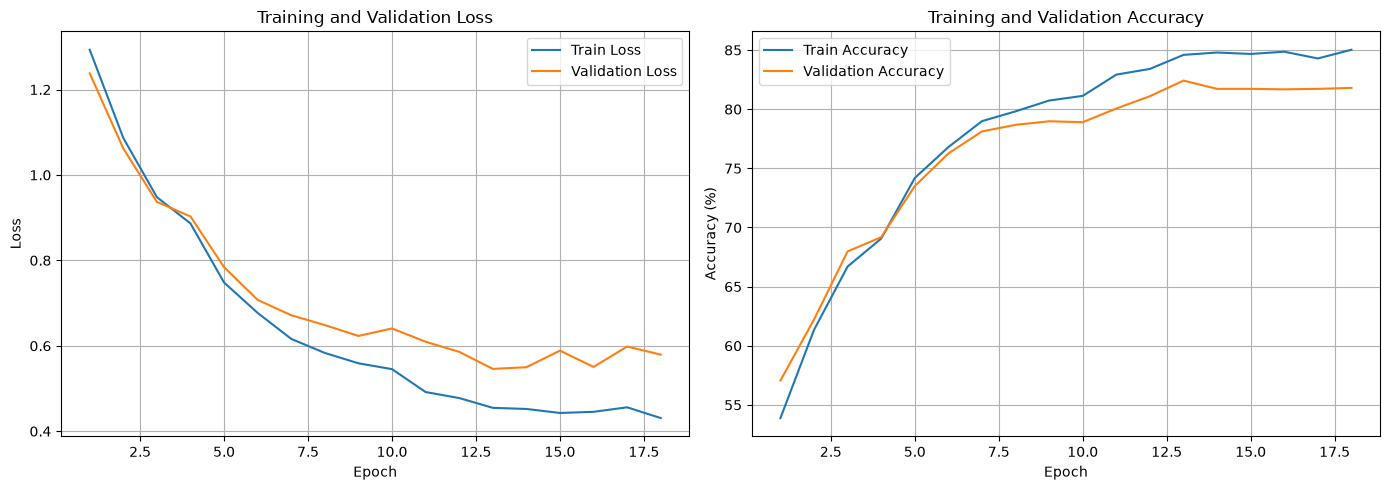

In [28]:
print(f"\n========== 开始 VGG11 训练 (epochs={epochs}) ==========")
trainer_vgg = Trainer(
    model=model_vgg,  # 待训练的 VGG11 模型
    trainloader=train_loader,  # 训练集 DataLoader
    valloader=val_loader,  # 验证集 DataLoader
    criterion=criterion,  # 损失函数（交叉熵）
    optimizer=optimizer_vgg,  # 优化器（Adam）
    device=device,  # 训练设备
    epochs=epochs,  # 最大训练轮数
    early_stopping=True,  # 启用早停
    patience=5,  # 早停容忍度: 连续 5 轮准确率未提升则停止
    save_path="best_model_vgg11_cifar10.pth",  # VGG11 最优权重保存路径
    early_stop_mode="acc",  # 早停依据: 验证集准确率
    maximize_acc=True,  # 准确率越大越好
    use_tensorboard=False  # 不使用 TensorBoard（若需要可设为 True）
)

trainer_vgg.train()  # 开始 VGG11 训练
trainer_vgg.plot(acc=True)  # 绘制训练/验证损失和准确率曲线

## 10. VGG11 验证集评估

In [29]:
# 使用训练好的最优模型在验证集上评估
val_loss_vgg, val_acc_vgg = trainer_vgg.evaluating(val_loader)  # 在验证集上评估
print(f"\n========== VGG11 验证集评估结果 ==========")  # 分隔标题
print(f"VGG11 - Val Loss: {val_loss_vgg:.4f}, Val Accuracy: {val_acc_vgg:.2f}%")  # 打印结果


========== VGG11 验证集评估结果 ==========
VGG11 - Val Loss: 0.5459, Val Accuracy: 82.42%


## 11. ResidualBlock —— ResNet 基本残差块
残差块的核心思想: 引入跳跃连接（skip connection），让梯度可以直接流过
公式: output = F(x) + x（当输入输出维度相同时）
优势: 缓解深层网络的梯度消失问题，使训练上百层的网络成为可能

In [30]:
class ResidualBlock(nn.Module):
    """
    ResNet 基本残差块（BasicBlock）

    结构:
      输入 x
      → Conv1(3×3, stride)→BatchNorm→ReLU
      → Conv2(3×3)→BatchNorm
      → 与跳跃连接(identity)相加
      → ReLU → 输出

    expansion = 1 表示输出通道数与 block 内部 planes 一致
    (Bottleneck 结构中 expansion = 4，这里 ResNet18 用 BasicBlock，expansion = 1)
    """
    expansion = 1  # 输出通道数膨胀系数，BasicBlock 为 1

    def __init__(self, in_planes, planes, stride=1, downsample=None):
        """
        初始化残差块

        参数:
            in_planes:  输入通道数
            planes:     中间/输出通道数（BasicBlock 中输出 = planes * expansion = planes）
            stride:     第一个卷积层的步长，控制空间降采样
            downsample: 下采样模块（nn.Sequential），用于匹配 identity 与 out 的维度
        """
        super().__init__()  # 调用父类 nn.Module 构造函数

        # 第一个 3×3 卷积: stride 可能为 2（用于降采样空间尺寸）
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)  # bias=False 因为后面有 BN
        self.bn1 = nn.BatchNorm2d(planes)  # 批归一化: 加速收敛、稳定训练
        self.relu = nn.ReLU(inplace=True)  # ReLU 激活（inplace 节省内存）
        # 第二个 3×3 卷积: stride=1，不改变空间尺寸
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)  # 保持尺寸
        self.bn2 = nn.BatchNorm2d(planes)  # 批归一化
        self.downsample = downsample  # 下采样模块: 当 in_planes != planes 或 stride != 1 时使用

    def forward(self, x):
        """
        残差块前向传播

        参数:
            x: 输入张量
        返回:
            输出张量（与输入同尺寸或降采样后尺寸）
        """
        identity = x  # 保存输入作为跳跃连接（shortcut/identity）

        out = self.conv1(x)  # 第一个 3×3 卷积
        out = self.bn1(out)  # 批归一化
        out = self.relu(out)  # ReLU 激活

        out = self.conv2(out)  # 第二个 3×3 卷积
        out = self.bn2(out)  # 批归一化（先不加 ReLU，等待与 identity 相加后再激活）

        if self.downsample is not None:  # 如果存在下采样模块
            identity = self.downsample(x)  # 对 identity 做 1×1 卷积调整通道/尺寸，使其与 out 匹配

        out += identity  # 残差连接: F(x) + x（逐元素相加）
        out = self.relu(out)  # 相加后再 ReLU 激活
        return out  # 返回残差块输出

## 12. ResNet18 —— 18 层残差卷积神经网络
ResNet18 结构（针对 CIFAR-10 适配，32×32 输入）:
  conv1: 3×3 Conv(3→64) + BN + ReLU（stride=1，不用 7×7，因为图片小）
  layer1: 2×ResidualBlock(64→64, stride=1)   → 32×32×64
  layer2: 2×ResidualBlock(64→128, stride=2)  → 16×16×128
  layer3: 2×ResidualBlock(128→256, stride=2) → 8×8×256
  layer4: 2×ResidualBlock(256→512, stride=2) → 4×4×512
  AdaptiveAvgPool2d→(1×1×512) → Flatten → FC(512→10)
与标准 ImageNet ResNet18 的区别:
  1. conv1 使用 3×3 卷积而非 7×7（CIFAR-10 图片只有 32×32）
  2. 去掉第一个 MaxPool 层（保留更多空间信息）
  3. 全连接层输出从 1000 改为 10

In [31]:
class ResNet18(nn.Module):
    """
    自定义 ResNet18 —— 用于 CIFAR-10 分类（32×32 输入）

    参数量: 约 11,173,962

    结构:
      conv1:  3×3, 3→64, stride=1, padding=1, no bias
      bn1 + ReLU
      layer1: [ResidualBlock(64→64)] × 2, stride=1
      layer2: [ResidualBlock(64→128)] × 2, stride=2（第一个 block 下采样）
      layer3: [ResidualBlock(128→256)] × 2, stride=2（第一个 block 下采样）
      layer4: [ResidualBlock(256→512)] × 2, stride=2（第一个 block 下采样）
      AdaptiveAvgPool2d(1,1) → Flatten → FC(512, 10)
    """

    def __init__(self, num_classes=10):
        """
        初始化 ResNet18

        参数:
            num_classes: 输出类别数，默认 10
        """
        super().__init__()  # 调用父类构造函数

        self.in_planes = 64  # 当前输入通道数追踪变量，用于 _make_layer 中自动推算

        # ---- 初始卷积层（替代 ImageNet 的 7×7 卷积） ----
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # 3→64 通道，保持 32×32
        self.bn1 = nn.BatchNorm2d(64)  # 批归一化
        self.relu = nn.ReLU(inplace=True)  # ReLU 激活

        # ---- 4 个残差阶段 ----
        self.layer1 = self._make_layer(64, 2, stride=1)  # 阶段1: 64 通道, 2 个 block, 输出 32×32
        self.layer2 = self._make_layer(128, 2, stride=2)  # 阶段2: 128 通道, 2 个 block, 输出 16×16
        self.layer3 = self._make_layer(256, 2, stride=2)  # 阶段3: 256 通道, 2 个 block, 输出 8×8
        self.layer4 = self._make_layer(512, 2, stride=2)  # 阶段4: 512 通道, 2 个 block, 输出 4×4

        # ---- 全局平均池化 + 全连接分类器 ----
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # 自适应池化: (batch,512,4,4)→(batch,512,1,1)
        # expansion=1（BasicBlock），输出通道数 = 512 * 1 = 512
        self.fc = nn.Linear(512 * ResidualBlock.expansion, num_classes)  # 全连接: 512 → 10

    def _make_layer(self, planes, blocks, stride):
        """
        构建一个残差阶段（layer）

        参数:
            planes: 该阶段中每个 block 的输出通道数
            blocks: 该阶段包含的 ResidualBlock 数量
            stride: 第一个 block 的步长（用于空间降采样）
        返回:
            nn.Sequential: 由 blocks 个 ResidualBlock 组成的阶段
        """
        downsample = None  # 下采样模块，初始为 None
        layers = []  # 用于存放该阶段所有 block 的列表

        # 判断是否需要下采样: stride != 1 或 输入/输出通道数不匹配
        if stride != 1 or self.in_planes != planes * ResidualBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_planes, planes * ResidualBlock.expansion,  # 输入通道→输出通道
                    kernel_size=1, stride=stride, bias=False  # 1×1 卷积用于调整通道数
                ),
                nn.BatchNorm2d(planes * ResidualBlock.expansion),  # BN 归一化
            )

        # 第一个 block 可能带 stride 和 downsample
        layers.append(ResidualBlock(self.in_planes, planes, stride, downsample))  # 添加第一个残差块
        self.in_planes = planes * ResidualBlock.expansion  # 更新 in_planes 为当前输出通道数
        # 剩余的 blocks: stride=1，不需要 downsample
        for _ in range(1, blocks):  # 从第 2 个到第 blocks 个
            layers.append(ResidualBlock(self.in_planes, planes))  # stride 默认=1, downsample 默认=None

        return nn.Sequential(*layers)  # 用 Sequential 包装所有 block，顺序执行

    def forward(self, x):
        """
        前向传播

        参数:
            x: 输入张量，形状 (batch_size, 3, 32, 32)
        返回:
            logits: 形状 (batch_size, 10)
        """
        x = self.conv1(x)  # 初始 3×3 卷积: (batch,3,32,32)→(batch,64,32,32)
        x = self.bn1(x)  # 批归一化
        x = self.relu(x)  # ReLU 激活

        x = self.layer1(x)  # 阶段1: (batch,64,32,32)→(batch,64,32,32)
        x = self.layer2(x)  # 阶段2: (batch,64,32,32)→(batch,128,16,16)
        x = self.layer3(x)  # 阶段3: (batch,128,16,16)→(batch,256,8,8)
        x = self.layer4(x)  # 阶段4: (batch,256,8,8)→(batch,512,4,4)

        x = self.avgpool(x)  # 自适应平均池化: (batch,512,4,4)→(batch,512,1,1)
        x = torch.flatten(x, 1)  # 展平: (batch,512,1,1)→(batch,512)
        x = self.fc(x)  # 全连接输出: (batch,512)→(batch,10)

        return x  # 返回 logits

### 实例化 ResNet18 模型

In [32]:
model_resnet = ResNet18(num_classes=10)  # 创建 ResNet18 模型实例，10 分类
print("\n========== ResNet18 模型结构 ==========")  # 分隔标题
print(model_resnet)  # 打印模型结构概览


========== ResNet18 模型结构 ==========
ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
 

## 13. ResNet18 参数统计与前向传播验证

In [33]:
print("\n========== ResNet18 参数统计 ==========")  # 分隔标题
# 统计总参数量和可训练参数量
total_params_resnet = sum(p.numel() for p in model_resnet.parameters())  # 所有参数: 约 11,173,962
trainable_params_resnet = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)  # 可训练参数（应等于总参数量）
print(f"ResNet18 模型总参数量: {total_params_resnet:,}")  # 约 11.17M
print(f"ResNet18 可训练参数量: {trainable_params_resnet:,}")  # 约 11.17M


========== ResNet18 参数统计 ==========
ResNet18 模型总参数量: 11,173,962
ResNet18 可训练参数量: 11,173,962


### 前向传播验证
用随机生成的虚拟数据测试模型输入输出尺寸是否正确

In [34]:
dummy_input = torch.randn(4, 3, 32, 32)  # 模拟 batch_size=4, 3 通道, 32×32 的图片
output_resnet = model_resnet(dummy_input)  # 前向传播
print(f"ResNet18 输入 shape: {dummy_input.shape}")  # torch.Size([4, 3, 32, 32])
print(f"ResNet18 输出 shape: {output_resnet.shape}")  # torch.Size([4, 10])，说明模型正确

ResNet18 输入 shape: torch.Size([4, 3, 32, 32])
ResNet18 输出 shape: torch.Size([4, 10])


## 14. 模型计算图可视化 —— torchviz 画图（可看到残差连接）
torchviz.make_dot 基于 PyTorch 自动求导机制，将前向传播的计算图渲染为图像
残差连接 (skip connection) 在图中表现为绕过卷积/BN 层的"捷径"边
对比 VGG11（纯串联）和 ResNet18（含跳跃连接），可以直观理解残差结构
使用前需安装:
  pip install torchviz
  并确保系统已安装 graphviz（https://graphviz.org/download/）
  Windows: 下载安装后需将 graphviz/bin 添加到 PATH 环境变量

### 14.1 单个 ResidualBlock 残差块计算图
单独画一个残差块，最清晰地展示 skip connection（跳跃连接）

In [35]:
print("\n========== 绘制单个 ResidualBlock 残差块计算图 ==========")
# 创建一个独立的残差块实例（64 输入通道 → 64 输出通道，stride=1，无需 downsample）
single_res_block = ResidualBlock(in_planes=64, planes=64, stride=1, downsample=None)  # 最简单残差块：维度完全匹配
single_res_block.eval()  # 切换到评估模式，固定 BatchNorm 参数


========== 绘制单个 ResidualBlock 残差块计算图 ==========


ResidualBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)

In [36]:
# 构造一个小的随机输入 (batch_size=1, 64 通道, 32×32)，用于绘图
x_block = torch.randn(1, 64, 32, 32)  # 单张 64 通道 32×32 特征图，batch_size=1 使图更简洁
y_block = single_res_block(x_block)  # 前向传播: 经过 conv1→bn1→relu→conv2→bn2 → +identity → relu

In [38]:
# make_dot 生成计算图: params 传入模型参数字典，使图中显示参数节点
dot_block = make_dot(y_block, params=dict(single_res_block.named_parameters()))  # 创建计算图 DOT 对象
dot_block.format = 'png'  # 输出格式设为 PNG
dot_block.attr(rankdir='TB')  # TB=Top to Bottom，从上到下的布局
dot_block.render('ResidualBlock_computation_graph', cleanup=True)  # 渲染并保存为 ResidualBlock_computation_graph.png
print("已保存: ResidualBlock_computation_graph.png（可看到 identity 跳跃连接绕过两层卷积直接加到输出）")

已保存: ResidualBlock_computation_graph.png（可看到 identity 跳跃连接绕过两层卷积直接加到输出）


### 14.2 完整 ResNet18 计算图（小型输入）
画完整 ResNet18，batch_size=1 且使用更小的输入以控制图的大小

In [39]:
print("\n========== 绘制 ResNet18 完整计算图 ==========")
# 实例化一个新的 ResNet18（避免与训练用的模型混淆，确保在 CPU 上）
resnet_viz = ResNet18(num_classes=10)  # 创建可视化专用 ResNet18
resnet_viz.eval()  # 评估模式
x_viz = torch.randn(1, 3, 32, 32)  # batch_size=1 的虚拟输入
y_viz = resnet_viz(x_viz)  # 前向传播: 经过所有的 conv + 残差块 + pool + fc


========== 绘制 ResNet18 完整计算图 ==========


In [40]:
# 生成 ResNet18 完整计算图
dot_resnet = make_dot(y_viz, params=dict(resnet_viz.named_parameters()))  # 构建计算图
dot_resnet.format = 'png'  # 输出 PNG 格式
dot_resnet.attr(rankdir='TB')  # 从上到下布局
dot_resnet.render('ResNet18_computation_graph', cleanup=True)  # 保存为 ResNet18_computation_graph.png
print("已保存: ResNet18_computation_graph.png（图中可见每个残差块内的 AddBackward 节点即为跳跃连接）")

已保存: ResNet18_computation_graph.png（图中可见每个残差块内的 AddBackward 节点即为跳跃连接）


### 14.3 VGG11 计算图（对比：纯串联，无跳跃连接）

In [41]:
print("\n========== 绘制 VGG11 计算图（对比：无残差连接）==========")
# 实例化一个新的 VGG11（CPU 上运行）
vgg_viz = VGG11(num_classes=10)  # 创建可视化专用 VGG11
vgg_viz.eval()  # 评估模式
x_vgg = torch.randn(1, 3, 32, 32)  # batch_size=1 的虚拟输入
y_vgg = vgg_viz(x_vgg)  # 前向传播: 纯串联，无跳跃连接


========== 绘制 VGG11 计算图（对比：无残差连接）==========


In [42]:
# 生成 VGG11 计算图
dot_vgg = make_dot(y_vgg, params=dict(vgg_viz.named_parameters()))  # 构建计算图
dot_vgg.format = 'png'  # 输出 PNG
dot_vgg.attr(rankdir='TB')  # 从上到下
dot_vgg.render('VGG11_computation_graph', cleanup=True)  # 保存为 VGG11_computation_graph.png
print("已保存: VGG11_computation_graph.png（纯串联结构，无 AddBackward 跳跃连接节点，与 ResNet18 形成对比）")

已保存: VGG11_computation_graph.png（纯串联结构，无 AddBackward 跳跃连接节点，与 ResNet18 形成对比）


### 14.4 计算图解读提示

In [43]:
print("\n========== 计算图解读指南 ==========")
print("在生成的 PNG 图中:")
print("  - 蓝色矩形节点: 张量操作（Conv2d、BatchNorm2d、ReLU、MaxPool2d 等）")
print("  - 灰色椭圆节点: 参数张量（权重 weight、偏置 bias）")
print("  - AddBackward0 节点: 张量加法操作")
print("  - 残差连接特征: 在 ResidualBlock 图中，可以看到一条边直接从输入 identity")
print("    绕过 conv1→bn1→relu→conv2→bn2 路径，汇入最后一个 AddBackward0 加法节点")
print("  - VGG11 图中不会有这种绕过操作——每个节点都是严格串联的")
print("  - ResNet18 完整图中，layer2/layer3/layer4 的每个残差块都包含这样的跳跃连接")


========== 计算图解读指南 ==========
在生成的 PNG 图中:
  - 蓝色矩形节点: 张量操作（Conv2d、BatchNorm2d、ReLU、MaxPool2d 等）
  - 灰色椭圆节点: 参数张量（权重 weight、偏置 bias）
  - AddBackward0 节点: 张量加法操作
  - 残差连接特征: 在 ResidualBlock 图中，可以看到一条边直接从输入 identity
    绕过 conv1→bn1→relu→conv2→bn2 路径，汇入最后一个 AddBackward0 加法节点
  - VGG11 图中不会有这种绕过操作——每个节点都是严格串联的
  - ResNet18 完整图中，layer2/layer3/layer4 的每个残差块都包含这样的跳跃连接


## 15. ResNet18 训练准备与训练

In [44]:
# 优化器
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=lr)  # Adam 优化器（lr=0.001）

In [45]:
# 将模型移至设备
model_resnet = model_resnet.to(device)  # 模型参数迁移到 GPU/CPU

In [ ]:
print(f"\n========== 开始 ResNet18 训练 (epochs={epochs}) ==========")
# 创建 Trainer 并开始训练
trainer_resnet = Trainer(
    model=model_resnet,  # 待训练的 ResNet18 模型
    trainloader=train_loader,  # 训练集 DataLoader
    valloader=val_loader,  # 验证集 DataLoader
    criterion=criterion,  # 损失函数（交叉熵）
    optimizer=optimizer_resnet,  # 优化器（Adam）
    device=device,  # 训练设备
    epochs=epochs,  # 最大训练轮数
    early_stopping=True,  # 启用早停
    patience=5,  # 早停容忍度: 连续 5 轮准确率未提升则停止
    save_path="best_model_resnet18_cifar10.pth",  # ResNet18 最优权重保存路径
    early_stop_mode="acc",  # 早停依据: 验证集准确率
    maximize_acc=True,  # 准确率越大越好
    use_tensorboard=False  # 不使用 TensorBoard（若需要可设为 True）
)

trainer_resnet.train()  # 开始 ResNet18 训练
trainer_resnet.plot(acc=True)  # 绘制训练/验证损失和准确率曲线


========== 开始 ResNet18 训练 (epochs=20) ==========
Epoch [1/20], Step [100/352], Loss: 1.3458
Epoch [1/20], Step [200/352], Loss: 1.0958
Epoch [1/20], Step [300/352], Loss: 1.2152


## 16. ResNet18 验证集评估

In [ ]:
# 使用训练好的最优模型在验证集上评估
val_loss_resnet, val_acc_resnet = trainer_resnet.evaluating(val_loader)  # 在验证集上评估
print(f"\n========== ResNet18 验证集评估结果 ==========")  # 分隔标题
print(f"ResNet18 - Val Loss: {val_loss_resnet:.4f}, Val Accuracy: {val_acc_resnet:.2f}%")  # 打印结果

## 17. VGG11 vs ResNet18 对比总结

In [ ]:
# 构建对比表格
print("\n" + "=" * 65)  # 打印分隔线
print("========== VGG11 vs ResNet18 对比总结 ==========")  # 对比标题
print("=" * 65)  # 打印分隔线

print(f"{'模型':<15} {'总参数':<15} {'可训练参数':<15} {'验证准确率':<12}")  # 表头
print("-" * 57)  # 分隔线
print(f"{'VGG11':<15} {total_params_vgg:<15,} {trainable_params_vgg:<15,} {val_acc_vgg:<12.2f}%")  # VGG11 行
print(f"{'ResNet18':<15} {total_params_resnet:<15,} {trainable_params_resnet:<15,} {val_acc_resnet:<12.2f}%")  # ResNet18 行
print("-" * 57)  # 分隔线

### 详细分析

In [ ]:
print("\n结论分析:")  # 分析标题
print(f"  1. 参数量对比:")  # 参数量子标题
print(f"     VGG11 总参数: {total_params_vgg:,}（全部可训练）")  # ~9.29M
print(f"     ResNet18 总参数: {total_params_resnet:,}（全部可训练）")  # ~11.17M
print(f"     ResNet18 参数量略多于 VGG11，但通过残差结构获得了更好的训练效果")
print(f"  2. 网络结构对比:")  # 结构子标题
print(f"     VGG11: 纯串联结构，8 层卷积 + 3 层全连接，梯度需要逐层反向传播")
print(f"     ResNet18: 引入残差连接（skip connection），梯度可以直接流过，缓解梯度消失")
print(f"  3. 训练特性对比:")  # 训练特性子标题
print(f"     VGG11: 深层网络容易出现梯度消失/爆炸，需要较好的初始化策略")
print(f"     ResNet18: 残差连接使梯度能直接回传，训练更稳定，收敛更快")
print(f"  4. 适用场景:")  # 场景子标题
print(f"     VGG11: 结构简单、易于理解和修改，适合教学和快速原型验证")
print(f"     ResNet18: 残差结构通用性更强，准确率通常更高，适合追求性能的场景")
print(f"  5. 扩展建议:")  # 扩展子标题
print(f"     - 可以尝试更深层的 ResNet34/ResNet50 进一步提升准确率")
print(f"     - 可以结合数据增强（Cutout、Mixup）和余弦退火学习率调度进一步优化")
print(f"     - 在 Colab 环境中可使用 GPU 加速训练，大幅缩短训练时间")